# L5 · GD vs Momentum vs Adam on an elongated bowl

**One idea:** on the ill-conditioned loss $L(x,y)=x^2+50y^2$, plain GD zigzags,
momentum smooths the path, and Adam adapts the per-coordinate step size.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)

def optimize(make_opt, steps=60, start=(9.0, 1.0)):
    p = torch.tensor(start, requires_grad=True)
    opt = make_opt([p])
    path = [p.detach().clone().numpy()]
    for _ in range(steps):
        opt.zero_grad()
        loss = p[0]**2 + 50*p[1]**2        # elongated quadratic
        loss.backward()
        opt.step()
        path.append(p.detach().clone().numpy())
    return np.array(path)

paths = {
    "GD (lr=0.01)":        optimize(lambda pr: torch.optim.SGD(pr, lr=0.01)),
    "Momentum (0.9)":      optimize(lambda pr: torch.optim.SGD(pr, lr=0.01, momentum=0.9)),
    "Adam (lr=0.3)":       optimize(lambda pr: torch.optim.Adam(pr, lr=0.3)),
}
for name, path in paths.items():
    final = path[-1]
    print(f"{name:20s} final=({final[0]:+.3f}, {final[1]:+.3f})  loss={final[0]**2+50*final[1]**2:.4f}")

GD (lr=0.01)         final=(+2.678, +0.000)  loss=7.1716
Momentum (0.9)       final=(+0.013, -0.031)  loss=0.0467
Adam (lr=0.3)        final=(-0.457, +0.014)  loss=0.2181


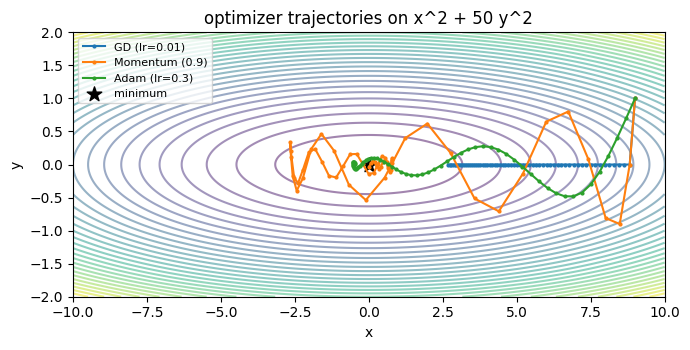

In [2]:
gx, gy = np.meshgrid(np.linspace(-10, 10, 200), np.linspace(-2, 2, 200))
Z = gx**2 + 50*gy**2

plt.figure(figsize=(7, 3.6))
plt.contour(gx, gy, Z, levels=30, cmap="viridis", alpha=0.5)
for name, path in paths.items():
    plt.plot(path[:,0], path[:,1], ".-", ms=4, label=name)
plt.scatter([0], [0], c="k", marker="*", s=120, label="minimum")
plt.legend(fontsize=8); plt.title("optimizer trajectories on x^2 + 50 y^2")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

## Takeaway
- **GD** takes tiny safe steps and crawls down the steep $y$-direction.
- **Momentum** accumulates velocity along the consistent $x$-direction and damps
  the cross-valley oscillation.
- **Adam** rescales each coordinate by its recent gradient magnitude, so it makes
  fast, well-balanced progress — a robust default.